# Gradient Boosting

<h2>Definition</h2>

<p>
Gradient Boosting is an ensemble machine learning algorithm that combines multiple weak learners 
(usually decision trees) sequentially to create a strong predictive model.
</p>

<p>
Each new model tries to correct the errors made by the previous models.
</p>

<hr>

<h2>Core Idea</h2>

<p>
Gradient Boosting starts with a simple prediction (generally the mean in regression) 
and gradually improves predictions by learning residual errors.
</p>

<pre>
Final Prediction = Initial Prediction + Corrections from all Trees
</pre>

<hr>

<h2>Working of Gradient Boosting</h2>

<h3>Step 1: Initialize Model</h3>

<p>
For regression, the model usually starts with the mean of target values.
</p>

<pre>
F₀(x) = mean(y)
</pre>

<hr>

<h3>Step 2: Calculate Residual Errors</h3>

<p>
Residual means the difference between actual and predicted values.
</p>

<pre>
Residual = Actual Value - Predicted Value
Residual = y - ŷ
</pre>

<hr>

<h3>Step 3: Train Weak Learner</h3>

<p>
A new decision tree is trained on these residual errors instead of original targets.
</p>

<hr>

<h3>Step 4: Update Prediction</h3>

<p>
The prediction is updated by adding the correction learned by the new tree.
</p>

<pre>
Fₘ(x) = Fₘ₋₁(x) + ηhₘ(x)
</pre>

<p>
Where:
</p>

<ul>
<li>Fₘ(x) → Updated prediction</li>
<li>Fₘ₋₁(x) → Previous prediction</li>
<li>hₘ(x) → New tree prediction</li>
<li>η → Learning rate</li>
</ul>

<hr>

<h3>Step 5: Repeat</h3>

<p>
The process repeats multiple times until the model minimizes the loss function.
</p>

<hr>

<h2>Why It Is Called Gradient Boosting</h2>

<p>
Gradient Boosting minimizes the loss function using gradient descent optimization.
</p>

<p>
The residuals are actually negative gradients of the loss function.
</p>

<pre>
Gradient = Direction of fastest decrease in loss
</pre>

<hr>

<h2>Loss Function</h2>

<p>
Loss function measures how wrong the prediction is.
</p>

<h3>Common Loss Function (Regression)</h3>

<pre>
L = (y - ŷ)²
</pre>

<p>
This is called Mean Squared Error (MSE).
</p>

<hr>

<h2>Learning Rate</h2>

<p>
Learning rate controls how much correction each tree contributes.
</p>

<pre>
Small Learning Rate → Slow but Stable Learning
Large Learning Rate → Fast but Risk of Overfitting
</pre>

<hr>

<h2>Main Intuition</h2>

<p>
Gradient Boosting gradually moves predictions closer to actual values.
</p>

<pre>
Start from Mean
      ↓
Find Error
      ↓
Learn Correction
      ↓
Add Correction
      ↓
Reduce Error
</pre>

<hr>

<h2>Advantages</h2>

<ul>
<li>High prediction accuracy</li>
<li>Works for regression and classification</li>
<li>Handles complex patterns well</li>
<li>Reduces bias effectively</li>
</ul>

<hr>

<h2>Disadvantages</h2>

<ul>
<li>Training is slower</li>
<li>Can overfit if too many trees are used</li>
<li>Sensitive to hyperparameters</li>
</ul>

<hr>

<h2>Difference Between AdaBoost and Gradient Boosting</h2>

<table border="1" cellpadding="8">
<tr>
<th>AdaBoost</th>
<th>Gradient Boosting</th>
</tr>

<tr>
<td>Focuses on wrong datapoints</td>
<td>Focuses on residual errors</td>
</tr>

<tr>
<td>Changes sample weights</td>
<td>Uses gradients/loss minimization</td>
</tr>

<tr>
<td>Mainly classification-oriented</td>
<td>Works strongly for regression and classification</td>
</tr>

<tr>
<td>Sequential weighted learning</td>
<td>Sequential error correction</td>
</tr>
</table>

<hr>

<h2>Popular Implementations</h2>

<ul>
<li>XGBoost</li>
<li>LightGBM</li>
<li>CatBoost</li>
<li>GradientBoostingClassifier</li>
<li>GradientBoostingRegressor</li>
</ul>

<hr>

<h2>One-Line Summary</h2>

<p>
Gradient Boosting builds a strong model by sequentially training weak learners 
to reduce the residual errors of previous models.
</p>


In [1]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor,plot_tree
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import pandas as pd
import numpy as np

In [2]:
df=df = pd.read_csv("possum.csv")
le=LabelEncoder()
# encoding class values
df['sex'] = le.fit_transform(df['sex'])
df['Pop'] = le.fit_transform(df['Pop'])
si=SimpleImputer(strategy='most_frequent')
# imputing values
df['age']=si.fit_transform(df[['age']])
df['footlgth']=si.fit_transform(df[['footlgth']])
df.drop(columns=['case','Pop','sex','site'], inplace=True)
X=df.iloc[:,0:-1]
y=df.iloc[:,-1]
X_train,X_test,y_train,y_test=train_test_split(X,y,random_state=42)

In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV

ensemble_model = GradientBoostingRegressor()

param_grid = {
    'n_estimators': [500,700,1000],
    'learning_rate': [0.01,0.1,],
    'max_depth': [2, 3, 5,6,8],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

gcv = GridSearchCV(
    estimator=ensemble_model,
    param_grid=param_grid,
    cv=5,
    verbose=2,
    n_jobs=-1
)

gcv.fit(X_train, y_train)

Fitting 5 folds for each of 540 candidates, totalling 2700 fits


GridSearchCV(cv=5, estimator=GradientBoostingRegressor(), n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1],
                         'max_depth': [2, 3, 5, 6, 8],
                         'max_features': ['sqrt', 'log2'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [500, 700, 1000]},
             verbose=2)

In [4]:
best_model = gcv.best_estimator_
pred = best_model.predict(X_test)
from sklearn.metrics import r2_score
score = r2_score(y_test, pred)
print(score)

0.17690958180012228


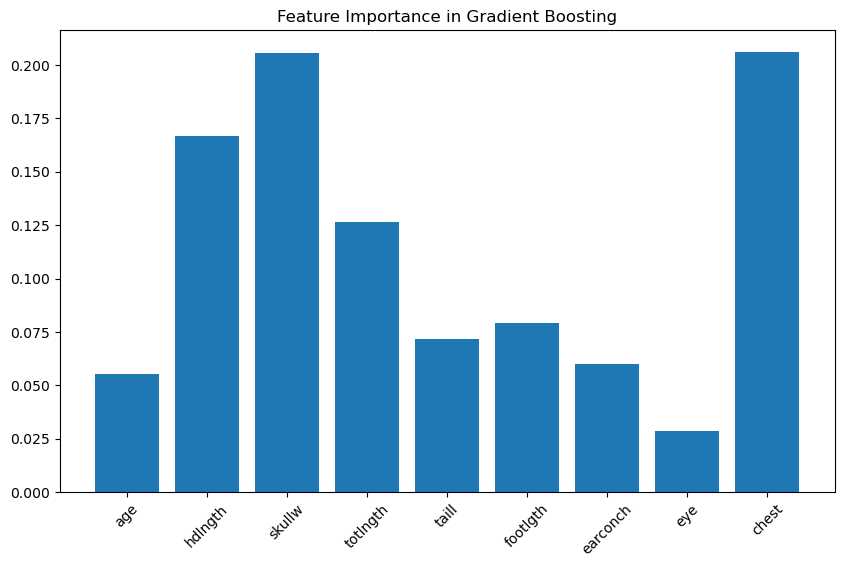

In [5]:
import matplotlib.pyplot as plt
importance = best_model.feature_importances_

features = X.columns

plt.figure(figsize=(10,6))

plt.bar(features, importance)

plt.xticks(rotation=45)

plt.title("Feature Importance in Gradient Boosting")

plt.show()